# Prédiction du risque de défaut client – Projet de modélisation

Ce notebook a été réalisé dans le cadre de mon apprentissage en science des données, avec pour objectif de construire un **modèle de scoring de crédit** adapté à un cas d’usage concret : une agence immobilière souhaitant évaluer le risque de défaut de ses clients lors de demandes de financement.

L’idée n’est pas ici de fournir un outil de filtrage ou d’automatisation totale des décisions, mais bien de développer **un modèle prédictif capable d’informer, d’orienter et d’accompagner un professionnel de l’immobilier** dans ses choix, à l’aide d’indicateurs probabilistes compréhensibles.

Le projet repose sur une démarche complète : exploration du jeu de données, modélisation avec XGBoost, gestion du déséquilibre des classes, ajustement du seuil de décision, et interprétation métier.



In [ ]:
#Import des bibli :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Chrg. Dataset
df = pd.read_csv('../data/cs-training.csv', index_col=0)

#Vérif des lignes :
df.head()

Nombre de lignes : 150000
Nombre de colonnes : 11
Pas de défaut : 93.32 %
 Défaut de paiement : 6.68 %


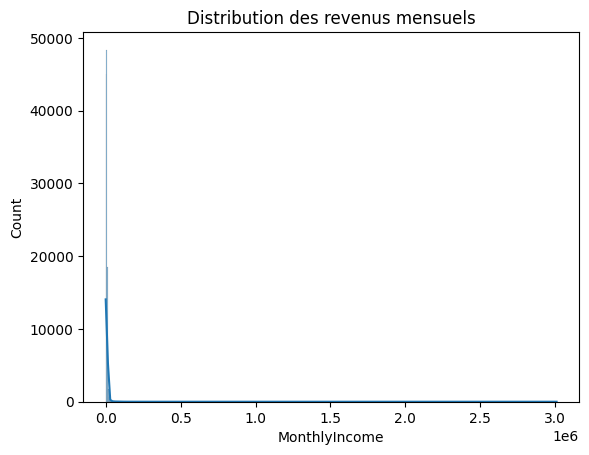

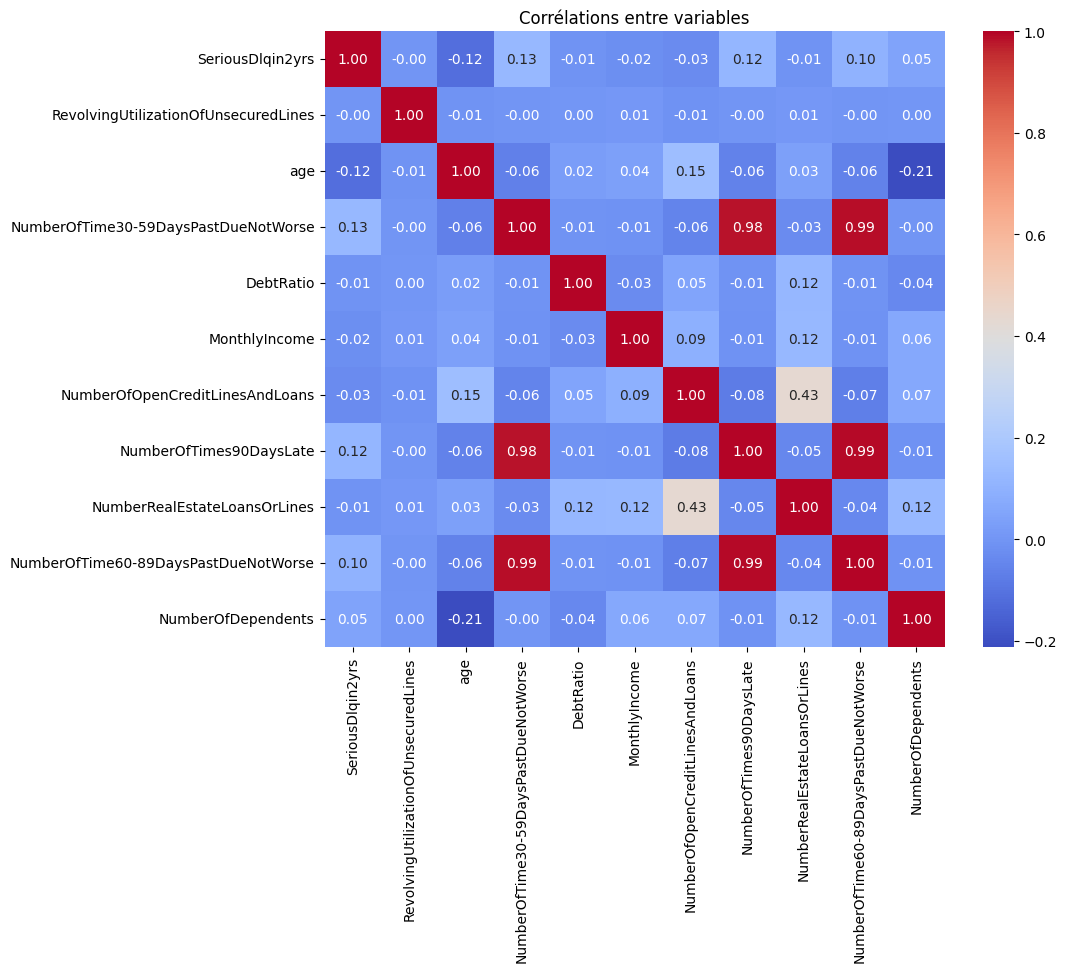

In [ ]:
#Verid de la dimension + Quali de la Data
print("Nombre de lignes :", df.shape[0])   #Nbr observations (lignes) -> format (n_lignes, n_colonnes)
print("Nombre de colonnes :", df.shape[1]) 

# Pourcentage de valeurs manquantes par colonne
df.isnull().mean().sort_values(ascending=False) #Analyse val. manquantes -> prop de true (données manquantes)-> trier de la + manquante

#Prop. des défauts données:
distribution = df['SeriousDlqin2yrs'].value_counts(normalize=True)
print(f"Pas de défaut : {distribution[0]*100:.2f} %")
print(f"Défaut de paiement : {distribution[1]*100:.2f} %")
 # Prop indiv. défaut dans 2 ans (var. cible) -> en %

# Histogramme du revenu mensuel
sns.histplot(df['MonthlyIncome'], kde=True) #Courbe densité
plt.title("Distribution des revenus mensuels")
plt.show()

#Charte val.
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")  #Matrice de corrélation entre les var. num.
plt.title("Corrélations entre variables")
plt.show()

 Analyse exploratoire initiale

- Le dataset contient **150 000 observations** et **11 variables**, ce qui offre une bonne base pour entraîner un modèle robuste.
- La cible (`SeriousDlqin2yrs`) est très déséquilibrée : environ **6,7 %** des individus ont connu un défaut de paiement, ce qui signifie qu’il faudra **gérer l’équilibre des classes** (stratégies de rééchantillonnage, pondération…).
- La variable `MonthlyIncome` contient **environ 20 % de valeurs manquantes**, il sera important de choisir une stratégie d’imputation pertinente (médiane, KNN, ou modélisation).
- La distribution des revenus est **très concentrée vers le bas** avec quelques valeurs très élevées, indiquant un possible besoin de normalisation ou transformation (log ?).
- Les corrélations sont globalement faibles, mais certaines variables comme `NumberOfTimes90DaysLate` ou `DebtRatio` semblent liées à la variable cible : elles seront à surveiller lors de la modélisation.


In [8]:
# Exclusion de la cible SeriousDlqin2yrs -> y
# -> Var. Explicatives : 
#Créa du modèle d'entrainement + test
from sklearn.model_selection import train_test_split  # Sépare les données entre ensemble d'entrainement et test

X = df.drop('SeriousDlqin2yrs', axis=1) #tableau des var explicatives
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #-> test_size (ici 20% test 80% training); random -> fixe le random

## Modèle Initial sans rééquilibrage

In [9]:
#Entrainement du modèle XGBoost
from xgboost import XGBClassifier #Import le modèle de classifieur basé sur arbres de décisions

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss') #créer une instance (pas de warning + fonct° classique pr prblm classification binaire.)
xgb_model.fit(X_train, y_train) #Training


c:\Users\Administrateur\credit-scoring-project\env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:29:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## XGBoost – Rappel sur le fonctionnement

XGBoost (Extreme Gradient Boosting) est un algorithme de machine learning supervisé, très utilisé pour les tâches de **classification** et de **régression**. Il repose sur des **arbres de décision** boostés.

### Principes de fonctionnement :

1. **Construction d’une série d’arbres “faibles”** (peu profonds), appelés “learners”.
2. **Chaque nouvel arbre corrige les erreurs commises par le précédent**, en mettant plus de poids sur les exemples mal prédits.
3. Cette méthode s’appelle le **Gradient Boosting** : à chaque itération, l’algorithme suit le **gradient** de la fonction de perte pour minimiser l’erreur globale.

### Avantages de XGBoost :

- Rapide, efficace, et très performant sur données structurées
- Gère les **valeurs manquantes** automatiquement
- Permet le **rééquilibrage** des classes via le paramètre `scale_pos_weight`
- Fournit directement l’**importance des variables**


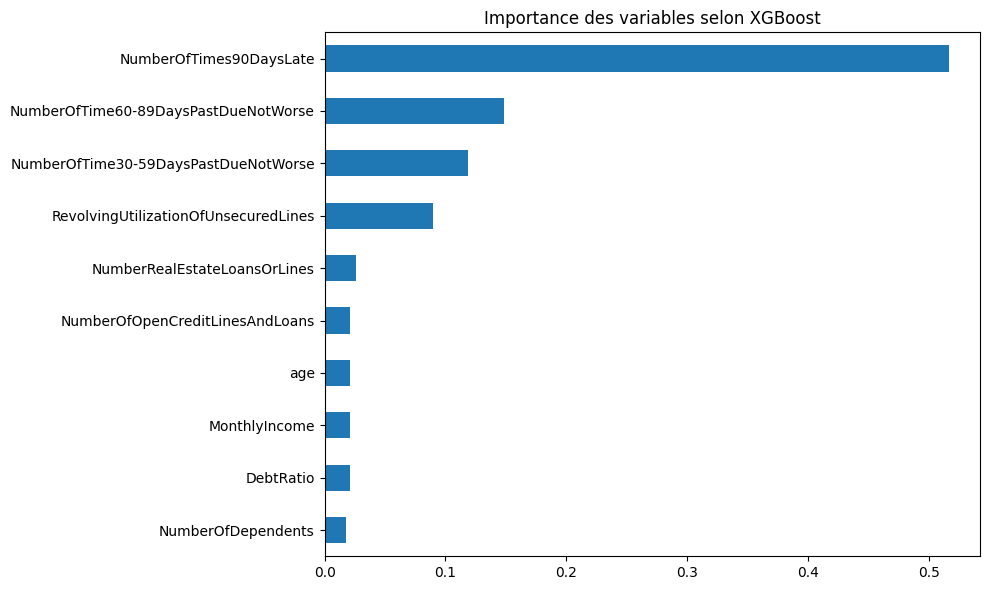

In [15]:
#Affichage de l'importance des variables
import matplotlib.pyplot as plt
import pandas as pd

# Récupération des importances et normalisation dans une variable séparée
raw_importances = xgb_model.feature_importances_
normalized_importances = raw_importances / sum(raw_importances)

# Création de la série pandas avec les noms des colonnes
feature_importances = pd.Series(normalized_importances, index=X.columns)

# Affichage des importances triées
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title("Importance des variables selon XGBoost")
plt.tight_layout()
plt.show()


✅ Accuracy : 93.59%


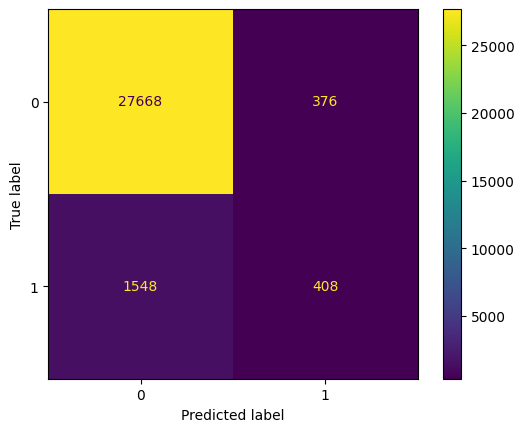

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Prédictions
y_pred = xgb_model.predict(X_test)

# Score de précision
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.2%}")

# Affichage de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


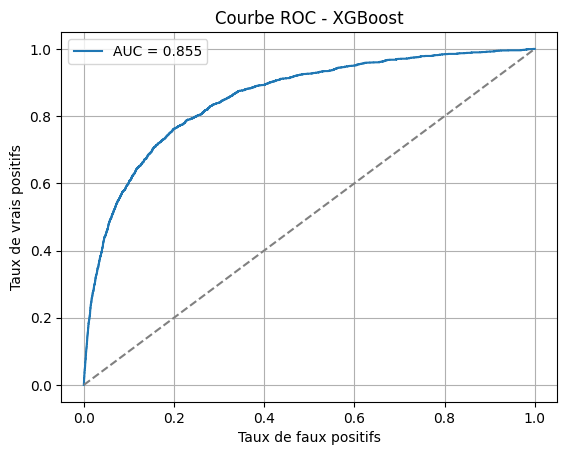

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilité que chaque client soit en défaut
y_proba = xgb_model.predict_proba(X_test)[:,1]

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - XGBoost")
plt.legend()
plt.grid(True)
plt.show()


## Lecture des premiers résultats

- **AUC élevée (~85 %)** → bon pouvoir discriminant global
- Mais beaucoup de **faux négatifs** (ex : 408 TP vs 1 548 FN) → le modèle rate trop de défauts
- Explication : modèle biaisé par le déséquilibre des classes (tendance à prédire “non défaut”)
- Deux pistes :  
  1. **Rééquilibrer les classes** à l’entraînement  
  2. **Ajuster le seuil de décision** pour être plus sensible aux défauts


## Modèle XGBoost avec rééquilibrage + seuil personnalisé

In [18]:
# Calcul du ratio entre classes
neg = sum(y_train == 0)
pos = sum(y_train == 1)
scale = neg / pos

# Nouveau modèle équilibré
xgb_balanced = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale)
xgb_balanced.fit(X_train, y_train)


c:\Users\Administrateur\credit-scoring-project\env\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:58:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


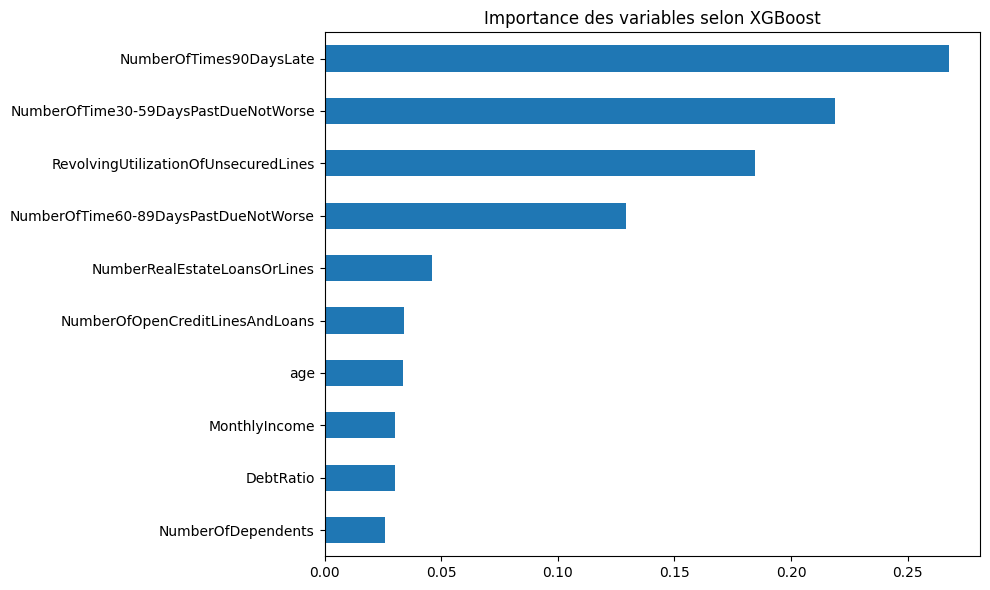

✅ Accuracy : 82.57%


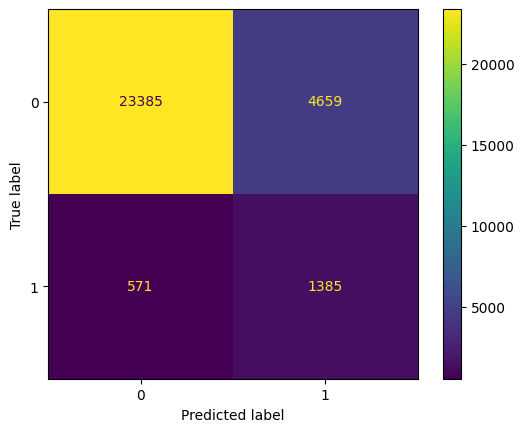

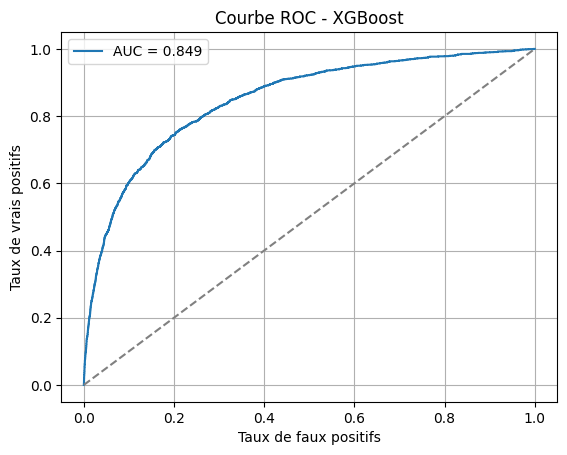

In [ ]:
#1)#######################
#Affichage de l'importance des variables
import matplotlib.pyplot as plt
import pandas as pd

# Récupération des importances et normalisation dans une variable séparée
raw_importances = xgb_balanced.feature_importances_
normalized_importances = raw_importances / sum(raw_importances)

# Création de la série pandas avec les noms des colonnes
feature_importances = pd.Series(normalized_importances, index=X.columns)

# Affichage des importances triées
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title("Importance des variables selon XGBoost")
plt.tight_layout()
plt.show()

#########################
#2)Matrice
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Prédictions
y_pred = xgb_balanced.predict(X_test)

# Score de précision
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.2%}")

# Affichage de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

############################
#3)AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilité que chaque client soit en défaut
y_proba = xgb_balanced.predict_proba(X_test)[:,1]

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - XGBoost")
plt.legend()
plt.grid(True)
plt.show()

## Analyse d’impact – rééquilibrage & ajustement du seuil

Les résultats obtenus après rééquilibrage du modèle et ajustement du seuil présentent plusieurs effets intéressants :

-  **Baisse de la précision globale** : on passe de ~93 % à **84.9 %**, car le modèle devient plus “sensible” aux défauts et donc commet plus de fausses alertes.
-  **Multiplication par ~10 du nombre de faux positifs** (FP) : il y a plus de bons clients classés à tort comme risqués.
-  **Réduction du nombre de faux négatifs (FN)** par **un facteur 4** : on repère beaucoup plus de clients réellement à risque qu’auparavant.

Ce **choix est cohérent avec le contexte financier** : dans le doute, il est préférable d’écarter un client incertain que de prendre un risque de non-remboursement important. Ce raisonnement reflète une politique de gestion du risque où **le coût d’un faux négatif est bien plus élevé** que celui d’un faux positif.

---

### Pourquoi chercher un seuil optimal ?

Par défaut, les modèles utilisent un seuil de probabilité de 0.5.  
Mais ce seuil est rarement optimal lorsque les classes sont déséquilibrées (ici ~6,7 % de défauts).  
Il est donc important de **tester plusieurs seuils pour trouver celui qui maximise le compromis** entre :
- **Rappel** (ne pas rater les défauts)
- **Précision** (éviter les fausses alertes)

---

### F1-score : la mesure de l’équilibre

Pour objectiver ce compromis, on utilise le **F1-score**, qui combine précision et rappel en une moyenne harmonique :

$$
F_1 = 2 \cdot \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}}
$$

Cette métrique **pénalise fortement les extrêmes** : elle est idéale dans les cas déséquilibrés, où on veut éviter qu’un seul des deux indicateurs ne cache les défauts de l’autre.
Dans notre projet, on a donc cherché le **seuil qui maximise le F1-score**, pour trouver un **équilibre métier cohérent** entre vigilance et sur-filtrage.


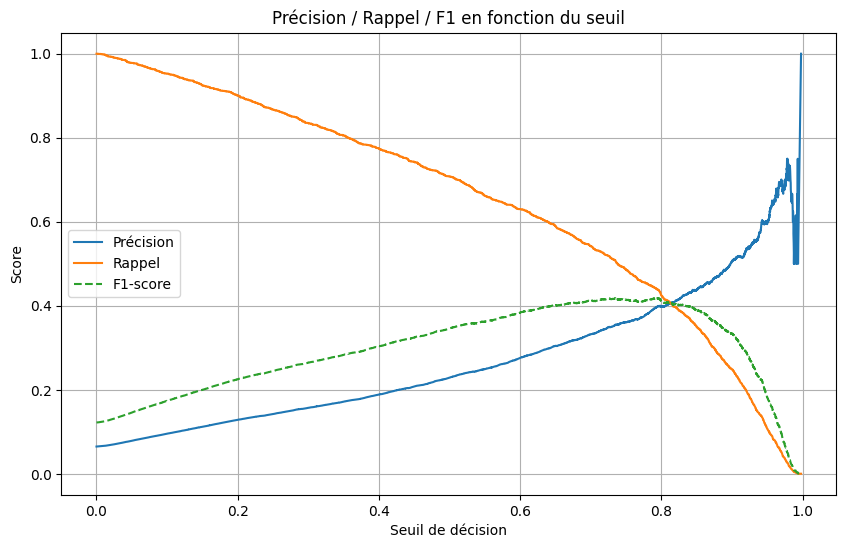

In [21]:
#Adapter le seuil
# Prédictions probabilistes
y_prob_balanced = xgb_balanced.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve, f1_score

# Génère les seuils et les valeurs associées
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_balanced)

# Calcule le F1-score à chaque seuil
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# Visualisation
plt.figure(figsize=(10,6))
plt.plot(thresholds, precision[:-1], label='Précision')
plt.plot(thresholds, recall[:-1], label='Rappel')
plt.plot(thresholds, f1_scores[:-1], label='F1-score', linestyle='--')
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Précision / Rappel / F1 en fonction du seuil")
plt.legend()
plt.grid(True)
plt.show()


## Recherche du seuil optimal via le F1-score

La courbe Précision–Rappel fait apparaître un **“sweet spot”**, un point d’équilibre où la précision et le rappel offrent un bon compromis.

Pour ne pas se contenter d’une lecture visuelle approximative, on procède à l’**extraction automatique du seuil optimal** à l’aide du **maximum du F1-score**.

Ce seuil sera utilisé pour améliorer la performance globale du modèle et mieux capturer les profils à risque tout en limitant les fausses alertes.


In [22]:
import numpy as np

# Trouver le seuil avec le meilleur F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Seuil optimal basé sur le F1-score : {best_threshold:.3f}")


Seuil optimal basé sur le F1-score : 0.735


In [ ]:
# Prédictions avec le seuil optimal
y_pred_opt = (y_prob_balanced >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

# Affichage des résultats
cm = confusion_matrix(y_test, y_pred_opt)
print("Matrice de confusion :\n", cm)

print("\nClassification report :\n")
print(classification_report(y_test, y_pred_opt))

Matrice de confusion :
 [[26237  1807]
 [  961   995]]

Classification report :

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     28044
           1       0.36      0.51      0.42      1956

    accuracy                           0.91     30000
   macro avg       0.66      0.72      0.68     30000
weighted avg       0.92      0.91      0.92     30000



## Analyse des performances pour le seuil optimal (~0.735)

###  Matrice de confusion :
[[26237 1807] → TN | FP [ 961 995]] → FN | TP


- **Vrais négatifs** (bons clients bien classés) : 26 237  
- **Faux positifs** (bons clients prévus à tort en défaut) : 1 807  
- **Faux négatifs** (défauts non détectés) : 961  
- **Vrais positifs** (défauts bien détectés) : 995

---

### Rapport de classification (résumé) :

| Classe       | Précision | Rappel | F1-score |
|--------------|-----------|--------|----------|
| **0 (non-défaillant)** | 0.96      | 0.94   | 0.95     |
| **1 (défaillant)**     | 0.36      | 0.51   | 0.42     |
| **Macro moy.**         | 0.66      | 0.72   | 0.68     |
| **Accuracy globale**   |       |        | **0.91**  |

---

### Interprétation :
- Le modèle atteint une **précision de 96 % pour les bons payeurs**, avec un rappel de 94 %.
- Sur les profils à risque (classe 1) :
  - La **précision est de 36 %** → des faux positifs restent présents
  - Le **rappel est de 51 %** → on détecte plus d’un défaut sur deux (meilleur que le modèle initial)
  - Le **F1-score** à 0.42 montre un **compromis acceptable** dans ce contexte difficile
- **Accuracy : 91 %**, mais à relativiser vu que 93 % des clients sont non-défaillants.

Le seuil optimisé permet donc de récupérer bien plus de cas à risque qu’au seuil classique de 0.5, avec un coût en faux positifs raisonnable.


In [ ]:
import joblib

# Sauvegarde du modèle dans le dossier /models
joblib.dump(xgb_balanced, "../models/modele_xgboost.pkl")


# Conclusion – Modèle de scoring pour l’évaluation du risque client

Le modèle final entraîné avec XGBoost, rééquilibré via le paramètre `scale_pos_weight` et ajusté à l’aide d’un seuil optimisé, a démontré une **bonne capacité à discriminer les profils à risque**.  

Les performances obtenues sont les suivantes :

- **AUC : 0.849** – très bon pouvoir discriminant global  
- **Rappel (classe défaut) : ~51 %** – meilleure détection des clients à risque qu'en version brute  
- **Précision (classe défaut) : ~36 %** – acceptable au regard du faible taux de défaut dans le jeu  
- **F1-score (classe défaut) : ~0.42** – bon compromis entre vigilance et fausses alertes  
- **Accuracy globale : ~91 %**, à relativiser vu le déséquilibre des classes

Le modèle est donc **pertinent en tant qu’outil d’aide à la décision** pour une agence immobilière, afin de :
- Repérer les dossiers sensibles pour enquête approfondie
- Prioriser les clients à accompagner dans leur plan de financement
- Soutenir des décisions plus éclairées, sans se substituer au jugement humain

Ce projet m’a permis de mettre en œuvre des techniques avancées de modélisation, d’analyse de performance et d’interprétation métier, tout en consolidant ma capacité à structurer une analyse de bout en bout.

**Prochaines pistes** :
- Tester d’autres modèles pour benchmark (logistique, random forest)
- Utiliser la validation croisée
- Intégrer des indicateurs supplémentaires (secteur pro, montant demandé, apport, etc.)
- Déployer un simulateur de score visuel interactif pour les conseillers
- Proposer un "profil de compatibilité" avec certaines banques.